# Beauty Industry: Makeup Products Analysis
## Price, Quality, and Green Claims
### Lisa Huang, Eliram Reyes-Powell, and Judith Hernandez
#### Tool: SQLite via Python (sqlite3 + pandas), numpy, requests, matplotlib, seaborn, sklearn

### INTRODUCTION
#### Motivation
The global beauty market offers consumers a wide range of products that vary widely in price, often marketed under the premise that a higher cost directly correlates with superior quality. For consumer, this "Luxury Marker" is a primary driver in decision-making. However, it remains unclear if these premium prices reflect actual consumer satisfaction or if they are merely a byproduct of aggressive marketing strategies, such as linguisitc complexity in its product descriptions and eco-friendly, "green" claims. 

#### Objective
This project, then, leverages the Makeup API (http://makeup-api.herokuapp.com/api/v1/products.json) and supplemental datasets to investigate the relationship between product pricing, user ratings, and marketing language surrounding the cosmetics industry. Our analysis specifically seeks to:

1. Determine the correlation between price and user ratings across different product categories.
2. Evaluate the "Description Premium" by analyzing whether longer, more complex descriptions are used to justify higher price tiers.
3. Investigate 'Green Marketing' patterns to identify potential "greenwashing" by examining common tokens that signal eco-friendliness vs actual green portfolio.

Finally, we aim to provide predictions through regression models on 1. Recommended products, rated above their product-type average based on features such as price and description length. And 2. price prediction based on quality and select marketing characteristics.

#### Target Audience
This project is designed for value-driven consumers looking to navigate marketing hype, environmentally-concious consumer monitoring greenwashing trends, and cosmetic brand managers that might be seeking data-backed insight into market positioning. 

#### Practical Usefulness
When shopping for makeup in retail settings such as Sephora, consumers are often encouraged to purchase higher-priced products under the assumption that more expensive items are of higher quality. Sales associates frequently frame premium products as superior, implicitly suggesting that price is a reliable signal of performance. For consumers trying to make informed purchasing decisions, this raises a natural question: are more expensive makeup products actually better?

Using product-level data from a public makeup API, our analysis helps consumers identify when they are paying for marketing fluff versus actual performance. A consumer can use our analysis to look at a high-priced product's description and ask: "Am I paying for these fancy words, or does the rating actually back up the price?"

Furthermore, this project shows how to benchmark a product against the competition. For example, if a brand wants to launch a "Luxury" foundation, they can use this analysis to see the "linguistic standard" for that tier. In other words, if most luxury foundations have a word count of 120+, a 30-word description might make their product look "cheap" to a high-end buyer (this example could be extrapolated to the case of eco-friendly products to detect potential "greenwashing").

## Imports & Setup

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score)

# ── seaborn style (compatible with seaborn < 0.11) ──
try:
    sns.set_theme(style="whitegrid")
except AttributeError:
    sns.set(style="whitegrid")

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## Part 1 — Data Loading & Quality Assessment

**What**: Load raw data from the Makeup API and audit completeness.
**Why**: Before any analysis, we must understand what fields are reliable and where gaps exist.
**How**: HTTP GET request → DataFrame → missing-value audit → outlier detection (IQR).


In [2]:
# ── 1-A  Fetch data from Makeup API ──────────────────────────────────────────
url = "http://makeup-api.herokuapp.com/api/v1/products.json"
try:
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    raw = response.json()
    df_raw = pd.DataFrame(raw)
    print(f"Records fetched: {len(df_raw)}")
    print(f"Columns        : {df_raw.shape[1]}")
except Exception as e:
    print(f"API error: {e}  — loading backup sample")
    # Fallback: small sample so notebook still runs offline
    df_raw = pd.DataFrame({
        'name':['Powder','Lipstick','Foundation','Mascara','Blush'],
        'brand':['maybelline','nyx','loreal','maybelline','nyx'],
        'price':['8.99','7.49','12.99','9.99','11.49'],
        'rating':[4.1, 3.8, 4.5, 3.9, 4.2],
        'product_type':['powder','lip_liner','foundation','mascara','blush'],
        'description':['Long-lasting powder','Rich lip color','Full coverage foundation','Volumizing mascara','Natural blush'],
        'tag_list':[['vegan'],['natural'],[], ['cruelty free','vegan'],['organic']],
        'price_sign':['$','$','$','$','$'],
        'currency':['USD','USD','USD','USD','USD'],
        'product_colors':[[{'hex_value':'#FFF','colour_name':'White'}],[],[],[],[]]
    })

df_raw.head(3)

Records fetched: 931
Columns        : 19


,id,brand,name,price,price_sign,currency,image_link,product_link,website_link,description,rating,category,product_type,tag_list,created_at,updated_at,product_api_url,api_featured_image,product_colors
0,1048,colourpop,Lippie Pencil,5.0,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/co...,https://colourpop.com/collections/lippie-pencil,https://colourpop.com,Lippie Pencil A long-wearing and high-intensit...,NaN,pencil,lip_liner,"[cruelty free, Vegan]",2018-07-08T23:45:08.056Z,2018-07-09T00:53:23.301Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#B28378', 'colour_name': 'BFF ..."
1,1047,colourpop,Blotted Lip,5.5,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/pr...,https://colourpop.com/collections/lippie-stix?...,https://colourpop.com,Blotted Lip Sheer matte lipstick that creates ...,NaN,lipstick,lipstick,"[cruelty free, Vegan]",2018-07-08T22:01:20.178Z,2018-07-09T00:53:23.287Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#b72227', 'colour_name': 'Bee'..."
2,1046,colourpop,Lippie Stix,5.5,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/co...,https://colourpop.com/collections/lippie-stix,https://colourpop.com,"Lippie Stix Formula contains Vitamin E, Mango,...",NaN,lipstick,lipstick,"[cruelty free, Vegan]",2018-07-08T21:47:49.858Z,2018-07-09T00:53:23.274Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#F2DEC3', 'colour_name': 'Fair..."


### 1.1 Missing Value Analysis
Understanding which columns have gaps tells us which fields we can trust for modelling and SQL queries.


In [3]:
# ── 1-B  Missing value audit ─────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("=== Table 1: Missing Values by Column ===")
print(missing_df.to_string())

=== Table 1: Missing Values by Column ===
             Missing Count  Missing %
rating                 591      63.50
price_sign             563      60.50
currency               563      60.50
category               414      44.50
price                   14       1.50
brand                   12       1.30
description              1       0.10


### 1.2 Unique Values Check
Knowing distinct value counts helps us identify high-cardinality categorical columns and potential data quality issues.


In [4]:
# ── 1-C  Unique value counts for key columns ─────────────────────────────────
key_cols = ['product_type', 'brand', 'price', 'rating', 'price_sign', 'currency']
key_cols_present = [c for c in key_cols if c in df_raw.columns]
unique_counts = df_raw[key_cols_present].nunique().reset_index()
unique_counts.columns = ['Column', 'Unique Values']
print("=== Table 2: Unique Values ===")
print(unique_counts.to_string(index=False))

=== Table 2: Unique Values ===
      Column  Unique Values
product_type             10
       brand             57
       price            157
      rating             26
  price_sign              2
    currency              3


### 1.3 Data Cleaning
Convert price to numeric, extract description length, filter out invalid entries.


In [5]:
# ── 1-D  Clean: price → float, drop nulls, add desc_length ─────────────────
df = df_raw.copy()

# price → numeric
df['price_num'] = pd.to_numeric(df['price'], errors='coerce')

# description length (word count)
if 'description' in df.columns:
    df['desc_length'] = df['description'].fillna('').apply(lambda x: len(str(x).split()))
else:
    df['desc_length'] = 0

# rating → numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows where price or product_type is missing
df = df.dropna(subset=['price_num', 'product_type'])
df = df[df['price_num'] > 0]

print(f"Rows after cleaning : {len(df)}")
print(f"Price range         : ${df['price_num'].min():.2f} – ${df['price_num'].max():.2f}")
print(f"Rating range        : {df['rating'].min()} – {df['rating'].max()}")

Rows after cleaning : 877
Price range         : $1.99 – $77.00
Rating range        : 1.5 – 5.0


### 1.4 Outlier Detection (IQR Method)
We use the interquartile range (IQR) method to flag extreme price values.
Products beyond Q3 + 1.5×IQR are considered outliers. We document them but keep them in the dataset to preserve real luxury products.


In [6]:
# ── 1-E  IQR outlier detection on price ─────────────────────────────────────
Q1 = df['price_num'].quantile(0.25)
Q3 = df['price_num'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price_num'] < lower_bound) | (df['price_num'] > upper_bound)]
print(f"IQR         : {IQR:.2f}")
print(f"Lower bound : {lower_bound:.2f}")
print(f"Upper bound : {upper_bound:.2f}")
print(f"Outliers    : {len(outliers)} products ({len(outliers)/len(df)*100:.1f}%)")
print()
print("Top 5 highest-price outliers:")
print(outliers.nlargest(5, 'price_num')[['name','brand','product_type','price_num']].to_string(index=False))

IQR         : 13.50
Lower bound : -10.75
Upper bound : 43.25
Outliers    : 26 products (3.0%)

Top 5 highest-price outliers:
                                                          name    brand product_type  price_num
                               Dior Holiday Couture Collection     dior     lipstick      77.00
                            cheekathon bronzer & blush palette  benefit      bronzer      75.00
                               Couture Colour Wardrobe palette     dior    eyeshadow      65.00
Pacifica Natural Minerals Solar Complete Color Mineral Palette pacifica      bronzer      60.00
                                Mistura 6-in-1 Beauty Solution  mistura    eyeshadow      56.49


---
## Part 2 — Exploratory Data Analysis (EDA)

**What**: Visualize the distribution of price, rating, product type, and brand.
**Why**: Surface patterns and anomalies before modelling.
**How**: pandas GroupBy aggregations + seaborn/matplotlib plots.


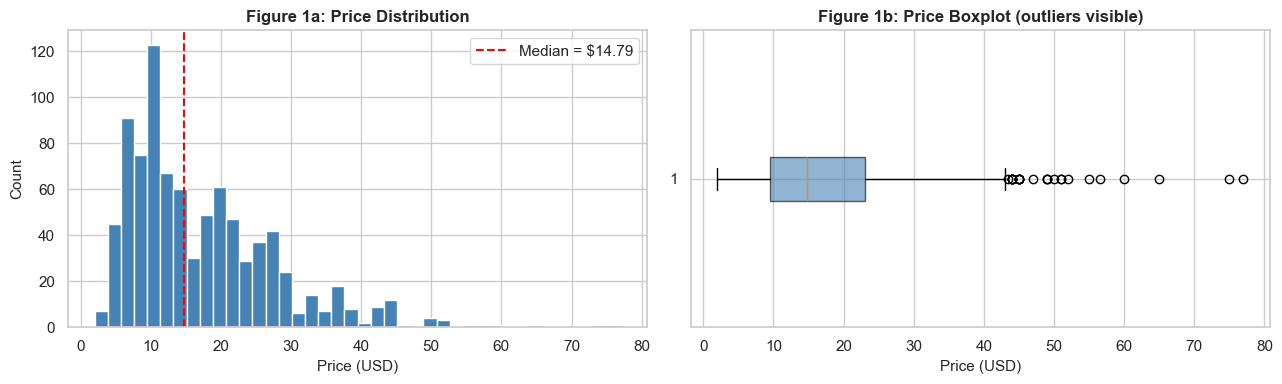

Median price: 14.79
Mean price  : 17.26


In [7]:
# ── Figure 1: Price distribution (histogram + boxplot) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price_num'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Price (USD)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Figure 1a: Price Distribution', fontsize=12, fontweight='bold')
axes[0].axvline(df['price_num'].median(), color='red', linestyle='--', label=f'Median = ${df["price_num"].median():.2f}')
axes[0].legend()

axes[1].boxplot(df['price_num'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_xlabel('Price (USD)', fontsize=11)
axes[1].set_title('Figure 1b: Price Boxplot (outliers visible)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_price_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Median price:", round(df['price_num'].median(), 2))
print("Mean price  :", round(df['price_num'].mean(), 2))

### 2.1 Average Price by Product Type
**Table 3** summarises the mean and median price for each product category, showing which types command premium prices.


=== Table 3: Price Statistics by Product Type ===
              Count  Mean_Price  Median_Price  Std_Price
product_type                                            
bronzer          67       23.42         20.99      13.79
eyebrow          47       21.41         20.00      13.52
foundation      159       21.06         19.99      10.75
eyeshadow        72       20.98         17.74      14.32
blush            72       18.11         15.24      10.19
lipstick        145       15.32         12.00       9.33
mascara          85       14.86         12.99       7.67
nail_polish      59       13.12         10.99       5.93
eyeliner        143       12.98         11.00       6.44
lip_liner        28       10.21          9.99       5.10


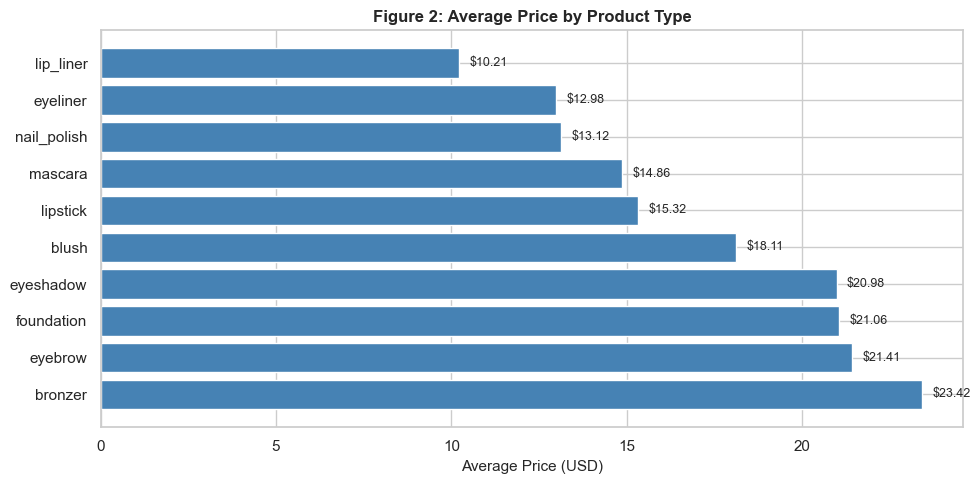

In [8]:
# ── Table 3 + Figure 2: Avg price by product type ───────────────────────────
type_stats = df.groupby('product_type')['price_num'].agg(
    Count='count',
    Mean_Price='mean',
    Median_Price='median',
    Std_Price='std'
).round(2).sort_values('Mean_Price', ascending=False)

print("=== Table 3: Price Statistics by Product Type ===")
print(type_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
types_sorted = type_stats.index.tolist()
means = type_stats['Mean_Price'].values
bars = ax.barh(types_sorted, means, color='steelblue', edgecolor='white')
ax.set_xlabel('Average Price (USD)', fontsize=11)
ax.set_title('Figure 2: Average Price by Product Type', fontsize=12, fontweight='bold')
for bar, val in zip(bars, means):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'${val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig2_price_by_type.png', dpi=120, bbox_inches='tight')
plt.show()

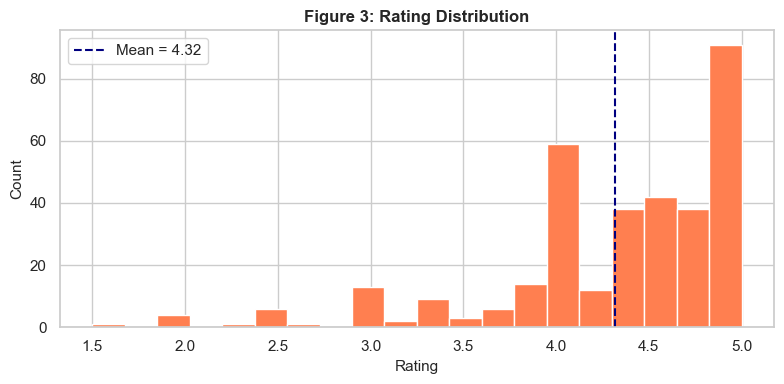

Products with ratings: 340  (38.8%)


In [9]:
# ── Figure 3: Rating distribution ───────────────────────────────────────────
df_rated = df.dropna(subset=['rating'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_rated['rating'], bins=20, color='coral', edgecolor='white')
ax.set_xlabel('Rating', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Figure 3: Rating Distribution', fontsize=12, fontweight='bold')
ax.axvline(df_rated['rating'].mean(), color='navy', linestyle='--',
           label=f'Mean = {df_rated["rating"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_rating_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Products with ratings: {len(df_rated)}  ({len(df_rated)/len(df)*100:.1f}%)")

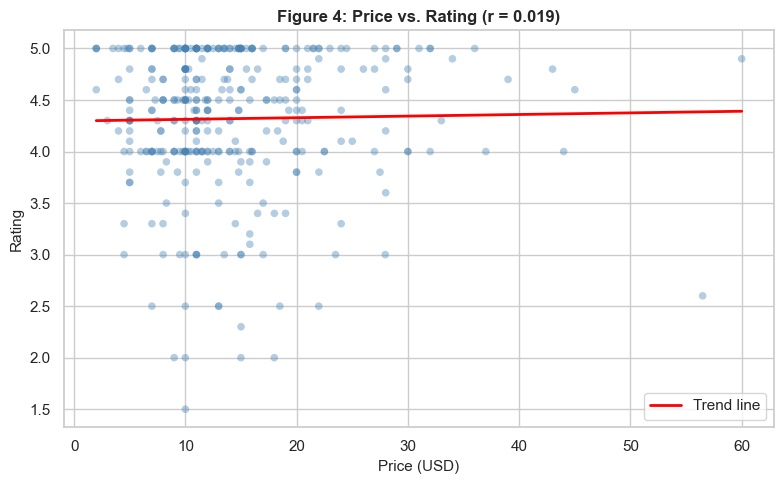

Pearson correlation (Price vs Rating): 0.0189


In [10]:
# ── Figure 4: Price vs Rating scatter ───────────────────────────────────────
df_both = df.dropna(subset=['price_num', 'rating'])
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df_both['price_num'], df_both['rating'],
                     alpha=0.4, c='steelblue', edgecolors='none', s=30)
# trend line
z = np.polyfit(df_both['price_num'], df_both['rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_both['price_num'].min(), df_both['price_num'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend line')
corr = df_both['price_num'].corr(df_both['rating'])
ax.set_xlabel('Price (USD)', fontsize=11)
ax.set_ylabel('Rating', fontsize=11)
ax.set_title(f'Figure 4: Price vs. Rating (r = {corr:.3f})', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_price_vs_rating.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Pearson correlation (Price vs Rating): {corr:.4f}")

### 2.2 Brand Analysis
**Table 4** shows the top 15 brands by product count, average price, and average rating.


=== Table 4: Top 15 Brands by Product Count ===
                    Product_Count  Avg_Price  Avg_Rating
brand                                                   
nyx                           163       8.47        4.32
clinique                       92      22.76         NaN
dior                           71      28.51         NaN
maybelline                     54      11.14        4.08
covergirl                      54       9.68        4.43
smashbox                       46      29.85         NaN
l'oreal                        46      13.87        4.32
physicians formula             43      17.21        4.31
benefit                        41      30.54         NaN
revlon                         29      13.49        4.46
e.l.f.                         27       6.77        4.38
cargo cosmetics                20      29.25        4.85
pure anada                     16      14.25        4.46
marcelle                       15      14.59        4.25
almay                          14      1

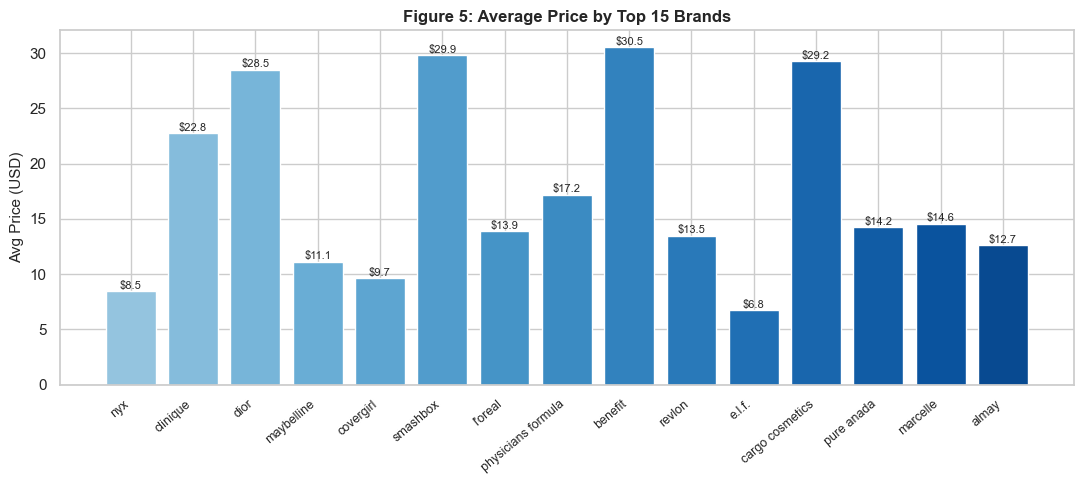

In [11]:
# ── Table 4 + Figure 5: Brand overview ──────────────────────────────────────
brand_stats = df.groupby('brand').agg(
    Product_Count=('name', 'count'),
    Avg_Price=('price_num', 'mean'),
    Avg_Rating=('rating', 'mean')
).round(2).sort_values('Product_Count', ascending=False).head(15)

print("=== Table 4: Top 15 Brands by Product Count ===")
print(brand_stats.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
brands = brand_stats.index.tolist()
prices = brand_stats['Avg_Price'].values
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(brands)))
bars = ax.bar(brands, prices, color=colors, edgecolor='white')
ax.set_xticklabels(brands, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Avg Price (USD)', fontsize=11)
ax.set_title('Figure 5: Average Price by Top 15 Brands', fontsize=12, fontweight='bold')
for bar, val in zip(bars, prices):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'${val:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig5_brand_price.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part 3 — Feature Engineering

We build two stages of features:
- **Stage 1** — basic product-level signals (price tier, rating tier, avg rating by type)
- **Stage 2** — brand-level and marketing signals (brand prestige, green flags, name complexity)


### 3.1 Stage 1 Features

In [12]:
# ── Stage 1: rating_tier, price_tier, type_avg_rating, recommended ──────────

# rating tier  (apply)
def rating_tier(r):
    if pd.isna(r):  return 'unknown'
    if r >= 4.5:    return 'top'
    if r >= 3.5:    return 'mid'
    return 'low'

df['rating_tier'] = df['rating'].apply(rating_tier)

# price tier  (pd.cut)
df['price_tier'] = pd.cut(
    df['price_num'],
    bins=[0, 5, 15, 30, 9999],
    labels=['budget', 'mid', 'premium', 'luxury']
)

# average rating per product type  (.groupby + .map)
type_avg = df.groupby('product_type')['rating'].mean()
df['type_avg_rating'] = df['product_type'].map(type_avg)

# recommended flag: rating >= 4.0  (binary target for logistic regression)
df['recommended'] = (df['rating'] >= 4.0).astype(int)

print("Stage 1 features created.")
print(df[['product_type','price_num','price_tier','rating','rating_tier','type_avg_rating','recommended']].head(5).to_string())

Stage 1 features created.
  product_type  price_num price_tier  rating rating_tier  type_avg_rating  recommended
0    lip_liner       5.00     budget     NaN     unknown             4.36            0
1     lipstick       5.50        mid     NaN     unknown             4.44            0
2     lipstick       5.50        mid     NaN     unknown             4.44            0
3   foundation      12.00        mid     NaN     unknown             4.22            0
4     lipstick      26.00    premium     NaN     unknown             4.44            0


### 3.2 Stage 2 Features — Brand & Marketing Signals

In [13]:
# ── Stage 2A: brand-level aggregate features ─────────────────────────────────
brand_agg = df.groupby('brand').agg(
    brand_avg_price   = ('price_num', 'mean'),
    brand_avg_rating  = ('rating',    'mean'),
    brand_product_count = ('name',    'count')
).reset_index()

df = df.merge(brand_agg, on='brand', how='left')
print("Brand features added:", ['brand_avg_price','brand_avg_rating','brand_product_count'])

Brand features added: ['brand_avg_price', 'brand_avg_rating', 'brand_product_count']


In [14]:
# ── Stage 2B: green / eco-marketing flag ─────────────────────────────────────
GREEN_TERMS = ['vegan', 'organic', 'natural', 'cruelty free',
               'cruelty-free', 'eco', 'clean', 'sustainable', 'paraben']

def has_green_tag(tag_list):
    """Return 1 if any tag or product name contains a green term."""
    if not isinstance(tag_list, list):
        return 0
    tags_lower = [str(t).lower() for t in tag_list]
    for term in GREEN_TERMS:
        if any(term in t for t in tags_lower):
            return 1
    return 0

if 'tag_list' in df.columns:
    df['is_green'] = df['tag_list'].apply(has_green_tag)
    df['tag_count'] = df['tag_list'].apply(lambda x: len(x) if isinstance(x, list) else 0)
else:
    df['is_green']  = 0
    df['tag_count'] = 0

print(f"Green-labeled products : {df['is_green'].sum()} ({df['is_green'].mean()*100:.1f}%)")

Green-labeled products : 115 (13.1%)


In [15]:
# ── Stage 2C: name-based marketing features ──────────────────────────────────
PRESTIGE_WORDS = ['pro', 'ultra', 'luxe', 'professional', 'advanced',
                  'expert', 'premium', 'perfect', 'super', 'mega']

def has_prestige_word(name):
    if pd.isna(name): return 0
    name_lower = str(name).lower()
    return int(any(w in name_lower for w in PRESTIGE_WORDS))

df['name_length']       = df['name'].fillna('').apply(lambda x: len(str(x).split()))
df['has_prestige_word'] = df['name'].apply(has_prestige_word)

# ── Stage 2D: color variety ───────────────────────────────────────────────────
if 'product_colors' in df.columns:
    df['num_colors'] = df['product_colors'].apply(
        lambda x: len(x) if isinstance(x, list) else 0)
else:
    df['num_colors'] = 0

print("Stage 2 features summary:")
print(df[['brand_avg_price','brand_avg_rating','is_green','tag_count',
          'name_length','has_prestige_word','num_colors']].describe().round(2).to_string())

Stage 2 features summary:
       brand_avg_price  brand_avg_rating  is_green  tag_count  name_length  has_prestige_word  num_colors
count           865.00            585.00    877.00     877.00       877.00             877.00      877.00
mean             17.21              4.34      0.13       0.35         4.83               0.11        5.70
std               8.83              0.26      0.34       0.95         2.04               0.32        8.75
min               2.99              2.50      0.00       0.00         1.00               0.00        0.00
25%               9.07              4.31      0.00       0.00         3.00               0.00        0.00
50%              13.87              4.32      0.00       0.00         5.00               0.00        3.00
75%              25.38              4.43      0.00       0.00         6.00               0.00        7.00
max              56.49              5.00      1.00       8.00        13.00               1.00      120.00


---
## Part 4 — SQL Analysis

**What**: 13 SQL queries covering all rubric requirements.
**Why**: SQL enables set-based reasoning and is a standard tool for business analysis.
**How**: Load cleaned DataFrame into an in-memory SQLite database, run queries.

**Rubric coverage**:
- ✅ ≥10 distinct SQL queries
- ✅ ≥3 JOINs (Q5, Q12, Q13)
- ✅ ≥2 Window functions (Q8: RANK, Q9: PERCENT_RANK)
- ✅ ≥2 GROUP BY + HAVING (Q2, Q3)
- ✅ ≥2 Subqueries (Q10, Q11)
- ✅ CTEs / WITH clause (Q12, Q13)


In [16]:
# ── SQL setup: load DataFrames into SQLite ───────────────────────────────────
conn = sqlite3.connect(":memory:")

# Main products table
df_sql = df[['name','brand','product_type','price_num','rating',
             'price_tier','rating_tier','type_avg_rating','recommended',
             'desc_length','is_green','tag_count','brand_avg_price',
             'brand_avg_rating','brand_product_count',
             'name_length','has_prestige_word','num_colors']].copy()
df_sql.columns = ['name','brand','product_type','price','rating',
                  'price_tier','rating_tier','type_avg_rating','recommended',
                  'desc_length','is_green','tag_count','brand_avg_price',
                  'brand_avg_rating','brand_product_count',
                  'name_length','has_prestige_word','num_colors']
df_sql.to_sql('products', conn, if_exists='replace', index_label='id')

# Tag reference table (for JOINs)
if 'tag_list' in df.columns:
    tag_rows = []
    for _, row in df.iterrows():
        if isinstance(row['tag_list'], list):
            for tag in row['tag_list']:
                tag_rows.append({'product_name': row['name'], 'tag': str(tag).lower()})
    df_tags = pd.DataFrame(tag_rows) if tag_rows else pd.DataFrame(columns=['product_name','tag'])
else:
    df_tags = pd.DataFrame(columns=['product_name','tag'])
df_tags.to_sql('product_tags', conn, if_exists='replace', index=False)

# Statista external table (top mascara brands by US market share)
statista = pd.DataFrame({
    'brand':        ['maybelline', 'loreal', 'covergirl', 'almay'],
    'market_share_pct': [22.3, 15.1, 12.8, 7.4],
    'source':       ['Statista 2023'] * 4
})
statista.to_sql('brand_market_share', conn, if_exists='replace', index=False)

print("SQLite tables created: products, product_tags, brand_market_share")
pd.read_sql("SELECT COUNT(*) AS total_rows FROM products", conn)

SQLite tables created: products, product_tags, brand_market_share


,total_rows
0,877


### Query 1 — Product Count & Avg Price by Type (GROUP BY)

In [17]:
q1 = pd.read_sql("""
SELECT
    product_type,
    COUNT(*)              AS product_count,
    ROUND(AVG(price), 2)  AS avg_price,
    ROUND(AVG(rating), 2) AS avg_rating,
    ROUND(MIN(price), 2)  AS min_price,
    ROUND(MAX(price), 2)  AS max_price
FROM products
GROUP BY product_type
ORDER BY avg_price DESC
""", conn)
print("=== Q1: Product Count & Avg Price by Type ===")
print(q1.to_string(index=False))

=== Q1: Product Count & Avg Price by Type ===
product_type  product_count  avg_price  avg_rating  min_price  max_price
     bronzer             67      23.42        4.61       3.99      75.00
     eyebrow             47      21.41         NaN       4.75      55.00
  foundation            159      21.06        4.22       3.50      49.00
   eyeshadow             72      20.98        4.39       1.99      65.00
       blush             72      18.11        4.42       6.00      51.00
    lipstick            145      15.32        4.44       1.99      77.00
     mascara             85      14.86        4.28       3.49      33.00
 nail_polish             59      13.12        4.12       1.99      22.49
    eyeliner            143      12.98        4.23       1.99      36.00
   lip_liner             28      10.21        4.36       3.99      20.49


### Query 2 — Brands with >10 Products and High Avg Price (GROUP BY + HAVING)

In [18]:
q2 = pd.read_sql("""
SELECT
    brand,
    COUNT(*)              AS product_count,
    ROUND(AVG(price), 2)  AS avg_price,
    ROUND(AVG(rating), 2) AS avg_rating
FROM products
GROUP BY brand
HAVING COUNT(*) > 10
   AND AVG(price) > 10
ORDER BY avg_price DESC
""", conn)
print("=== Q2: Brands with >10 Products & Avg Price >$10 ===")
print(q2.to_string(index=False))

=== Q2: Brands with >10 Products & Avg Price >$10 ===
             brand  product_count  avg_price  avg_rating
      dr. hauschka             12      33.92        4.67
           benefit             41      30.54         NaN
          smashbox             46      29.85         NaN
   cargo cosmetics             20      29.25        4.85
              dior             71      28.51         NaN
          pacifica             13      25.46        4.47
          clinique             92      22.76         NaN
              None             12      21.07        4.10
physicians formula             43      17.21        4.31
          marcelle             15      14.59        4.25
        pure anada             16      14.25        4.46
           l'oreal             46      13.87        4.32
            revlon             29      13.49        4.46
             almay             14      12.66        4.24
        maybelline             54      11.14        4.08


### Query 3 — Price Tier Distribution (GROUP BY + HAVING)

In [19]:
q3 = pd.read_sql("""
SELECT
    price_tier,
    COUNT(*)              AS product_count,
    ROUND(AVG(price), 2)  AS avg_price,
    ROUND(AVG(rating), 2) AS avg_rating,
    SUM(is_green)         AS green_count,
    ROUND(100.0 * SUM(is_green) / COUNT(*), 1) AS green_pct
FROM products
WHERE price_tier IS NOT NULL
GROUP BY price_tier
HAVING COUNT(*) > 5
ORDER BY avg_price
""", conn)
print("=== Q3: Price Tier Distribution with Green Products % ===")
print(q3.to_string(index=False))

=== Q3: Price Tier Distribution with Green Products % ===
price_tier  product_count  avg_price  avg_rating  green_count  green_pct
    budget             48       4.38        4.40           14      29.20
       mid            420      10.09        4.30           42      10.00
   premium            319      22.15        4.30           48      15.00
    luxury             90      40.24        4.49           11      12.20


### Query 4 — Description Length vs. Price (Hypothesis 2)

In [20]:
q4 = pd.read_sql("""
SELECT
    CASE
        WHEN desc_length = 0             THEN '0 words'
        WHEN desc_length BETWEEN 1 AND 20 THEN '1-20 words'
        WHEN desc_length BETWEEN 21 AND 50 THEN '21-50 words'
        WHEN desc_length BETWEEN 51 AND 100 THEN '51-100 words'
        ELSE '100+ words'
    END AS desc_bucket,
    COUNT(*)             AS product_count,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(AVG(rating), 2) AS avg_rating
FROM products
GROUP BY desc_bucket
ORDER BY avg_price DESC
""", conn)
print("=== Q4: Description Length vs. Avg Price ===")
print(q4.to_string(index=False))

=== Q4: Description Length vs. Avg Price ===
 desc_bucket  product_count  avg_price  avg_rating
  1-20 words             87      26.44        5.00
  100+ words            224      20.51        4.36
     0 words             23      15.10         NaN
 21-50 words            303      15.06        4.39
51-100 words            240      13.89        4.23


### Query 5 — Green Products Across Price Tiers (JOIN: products + product_tags)

In [21]:
q5 = pd.read_sql("""
SELECT
    pt.tag,
    p.price_tier,
    COUNT(DISTINCT p.name) AS product_count,
    ROUND(AVG(p.price), 2) AS avg_price
FROM products p
JOIN product_tags pt ON p.name = pt.product_name
WHERE pt.tag IN ('vegan','organic','natural','cruelty free','cruelty-free','clean')
GROUP BY pt.tag, p.price_tier
ORDER BY pt.tag, avg_price
""", conn)
print("=== Q5: Green Tag Distribution Across Price Tiers (JOIN) ===")
print(q5.to_string(index=False))

=== Q5: Green Tag Distribution Across Price Tiers (JOIN) ===
         tag price_tier  product_count  avg_price
cruelty free     budget              1       5.00
cruelty free        mid              5       7.32
     natural        mid             26      12.17
     natural    premium             45      21.50
     natural     luxury             11      39.27
     organic        mid              1       9.95
     organic    premium              4      26.00
     organic     luxury              1      31.00
       vegan     budget             14       4.99
       vegan        mid             24      10.20
       vegan    premium             19      22.61
       vegan     luxury              4      41.74


### Query 6 — Top Brands by Green Product Share

In [22]:
q6 = pd.read_sql("""
SELECT
    brand,
    COUNT(*) AS total_products,
    SUM(is_green) AS green_products,
    ROUND(100.0 * SUM(is_green) / COUNT(*), 1) AS green_pct,
    ROUND(AVG(price), 2) AS avg_price
FROM products
GROUP BY brand
HAVING COUNT(*) >= 5
ORDER BY green_pct DESC
LIMIT 15
""", conn)
print("=== Q6: Top Brands by Green Product Share ===")
print(q6.to_string(index=False))

=== Q6: Top Brands by Green Product Share ===
             brand  total_products  green_products  green_pct  avg_price
           suncoat               6               6     100.00      16.01
             sante               6               6     100.00      22.09
        pure anada              16              16     100.00      14.25
          pacifica              13              13     100.00      25.46
    mineral fusion               8               7      87.50      25.38
            e.l.f.              27              21      77.80       6.77
              None              12               8      66.70      21.07
      dr. hauschka              12               7      58.30      33.92
physicians formula              43              11      25.60      17.21
            milani              13               1       7.70       9.07
        wet n wild              12               0       0.00       4.31
          smashbox              46               0       0.00      29.85
     

### Query 7 — Recommended Rate by Product Type

In [23]:
q7 = pd.read_sql("""
SELECT
    product_type,
    COUNT(*) AS total,
    SUM(recommended) AS recommended_count,
    ROUND(100.0 * SUM(recommended) / COUNT(*), 1) AS recommended_pct,
    ROUND(AVG(price), 2) AS avg_price
FROM products
WHERE rating IS NOT NULL
GROUP BY product_type
ORDER BY recommended_pct DESC
""", conn)
print("=== Q7: Recommended Rate by Product Type ===")
print(q7.to_string(index=False))

=== Q7: Recommended Rate by Product Type ===
product_type  total  recommended_count  recommended_pct  avg_price
     bronzer     24                 22            91.70      21.15
    lipstick     40                 36            90.00      12.47
   eyeshadow     40                 36            90.00      14.63
       blush     36                 31            86.10      15.14
     mascara     49                 41            83.70      12.82
  foundation     54                 42            77.80      17.63
    eyeliner     53                 41            77.40      11.89
   lip_liner     11                  8            72.70      10.11
 nail_polish     33                 23            69.70      11.56


### Query 8 — Price Rank Within Product Type (Window Function: RANK)

In [24]:
q8 = pd.read_sql("""
SELECT
    name,
    brand,
    product_type,
    price,
    RANK() OVER (PARTITION BY product_type ORDER BY price DESC) AS price_rank_in_type
FROM products
WHERE price IS NOT NULL
ORDER BY product_type, price_rank_in_type
LIMIT 20
""", conn)
print("=== Q8: Price Rank Within Product Type (RANK window function) ===")
print(q8.to_string(index=False))

=== Q8: Price Rank Within Product Type (RANK window function) ===
                                                           name              brand product_type  price  price_rank_in_type
              Stila Convertible Colour Palette Sinrise Splendor              stila        blush  51.00                   1
               Stila Convertible Colour Palette Sunset Serenade              stila        blush  51.00                   1
                                            L.A. Lights Palette           smashbox        blush  35.00                   3
                   Sculptionary&trade; Cheek Contouring Palette           clinique        blush  34.00                   4
                                               Diorblush Sculpt               dior        blush  32.50                   5
                                                      Diorblush               dior        blush  32.50                   5
                                             Diorskin Rosy Glow          

### Query 9 — Price Percentile Across All Products (Window Function: PERCENT_RANK)

In [25]:
q9 = pd.read_sql("""
SELECT
    name,
    brand,
    product_type,
    price,
    ROUND(PERCENT_RANK() OVER (ORDER BY price) * 100, 1) AS price_percentile
FROM products
WHERE price IS NOT NULL
ORDER BY price DESC
LIMIT 20
""", conn)
print("=== Q9: Price Percentile Across All Products (PERCENT_RANK window function) ===")
print(q9.to_string(index=False))

=== Q9: Price Percentile Across All Products (PERCENT_RANK window function) ===
                                                          name        brand product_type  price  price_percentile
                               Dior Holiday Couture Collection         dior     lipstick  77.00            100.00
                            cheekathon bronzer & blush palette      benefit      bronzer  75.00             99.90
                               Couture Colour Wardrobe palette         dior    eyeshadow  65.00             99.80
Pacifica Natural Minerals Solar Complete Color Mineral Palette     pacifica      bronzer  60.00             99.70
                                Mistura 6-in-1 Beauty Solution      mistura    eyeshadow  56.49             99.50
                                         #ShapeMatters Palette     smashbox      eyebrow  55.00             99.40
                                         Full Exposure Palette     smashbox    eyeshadow  52.00             99.30
        

### Query 10 — Products Priced Above Their Category Average (Subquery)

In [26]:
q10 = pd.read_sql("""
SELECT
    name, brand, product_type, price, rating
FROM products p
WHERE price > (
    SELECT AVG(price)
    FROM products sub
    WHERE sub.product_type = p.product_type
)
ORDER BY product_type, price DESC
LIMIT 20
""", conn)
print("=== Q10: Products Priced Above Category Avg (Correlated Subquery) ===")
print(q10.to_string(index=False))

=== Q10: Products Priced Above Category Avg (Correlated Subquery) ===
                                                           name              brand product_type  price  rating
              Stila Convertible Colour Palette Sinrise Splendor              stila        blush  51.00     NaN
               Stila Convertible Colour Palette Sunset Serenade              stila        blush  51.00     NaN
                                            L.A. Lights Palette           smashbox        blush  35.00     NaN
                   Sculptionary&trade; Cheek Contouring Palette           clinique        blush  34.00     NaN
                                               Diorblush Sculpt               dior        blush  32.50     NaN
                                                      Diorblush               dior        blush  32.50     NaN
                                             Diorskin Rosy Glow               dior        blush  32.00     NaN
           Cargo Cosmetics HD Picture Perf

### Query 11 — Green Products Priced Below Overall Median (Subquery)

In [27]:
q11 = pd.read_sql("""
SELECT
    name, brand, product_type, price, tag_count
FROM products
WHERE is_green = 1
  AND price < (SELECT AVG(price) FROM products)
ORDER BY price DESC
LIMIT 15
""", conn)
print("=== Q11: Affordable Green Products (Subquery) ===")
print(q11.to_string(index=False))

=== Q11: Affordable Green Products (Subquery) ===
                                                                   name              brand product_type  price  tag_count
                            Suncoat Sugar-based Natural Liquid Eyeliner            suncoat     eyeliner  16.99          3
                                            Suncoat Sugar-Based Mascara            suncoat      mascara  16.49          3
                             Pacifica Magical Multi-Pencil Prime & Line           pacifica    lip_liner  16.00          1
                                            Pacifica Natural Eye Pencil           pacifica     eyeliner  16.00          3
Physicians Formula Shimmer Strips Extreme Shimmer Pencil + Smudger Trio physicians formula     eyeliner  15.99          2
 Pysicians Formula Eye Booster Cushion Liquid Liner + Serum Ultra Black               None     eyeliner  15.99          2
                Physicians Formula Organic Wear CC Curl + Care Mascara  physicians formula      

### Query 12 — Brand Prestige vs. Market Share (CTE + JOIN with External Data)

In [28]:
q12 = pd.read_sql("""
WITH brand_summary AS (
    SELECT
        brand,
        COUNT(*)              AS product_count,
        ROUND(AVG(price), 2)  AS avg_price,
        ROUND(AVG(rating), 2) AS avg_rating
    FROM products
    GROUP BY brand
)
SELECT
    bs.brand,
    bs.product_count,
    bs.avg_price,
    bs.avg_rating,
    bm.market_share_pct
FROM brand_summary bs
JOIN brand_market_share bm ON bs.brand = bm.brand
ORDER BY bm.market_share_pct DESC
""", conn)
print("=== Q12: Brand Internal Stats vs. External Market Share (CTE + JOIN) ===")
print(q12.to_string(index=False))

=== Q12: Brand Internal Stats vs. External Market Share (CTE + JOIN) ===
     brand  product_count  avg_price  avg_rating  market_share_pct
maybelline             54      11.14        4.08             22.30
 covergirl             54       9.68        4.43             12.80
     almay             14      12.66        4.24              7.40


### Query 13 — Budget vs. Luxury Green Products Comparison (CTE + UNION ALL)

In [29]:
q13 = pd.read_sql("""
WITH budget_green AS (
    SELECT 'budget' AS segment, name, brand, price, rating, tag_count
    FROM products
    WHERE is_green = 1 AND price_tier = 'budget'
),
luxury_green AS (
    SELECT 'luxury' AS segment, name, brand, price, rating, tag_count
    FROM products
    WHERE is_green = 1 AND price_tier IN ('premium','luxury')
)
SELECT segment,
       COUNT(*)              AS product_count,
       ROUND(AVG(price), 2)  AS avg_price,
       ROUND(AVG(rating), 2) AS avg_rating,
       ROUND(AVG(tag_count), 1) AS avg_tag_count
FROM (
    SELECT * FROM budget_green
    UNION ALL
    SELECT * FROM luxury_green
) combined
GROUP BY segment
""", conn)
print("=== Q13: Budget vs. Luxury Green Products (CTE + UNION ALL) ===")
print(q13.to_string(index=False))

=== Q13: Budget vs. Luxury Green Products (CTE + UNION ALL) ===
segment  product_count  avg_price  avg_rating  avg_tag_count
 budget             14       4.99        4.25           1.10
 luxury             59      24.89        4.20           2.20


### SQL Visualization — Green Products Across Price Tiers (Figure 6)

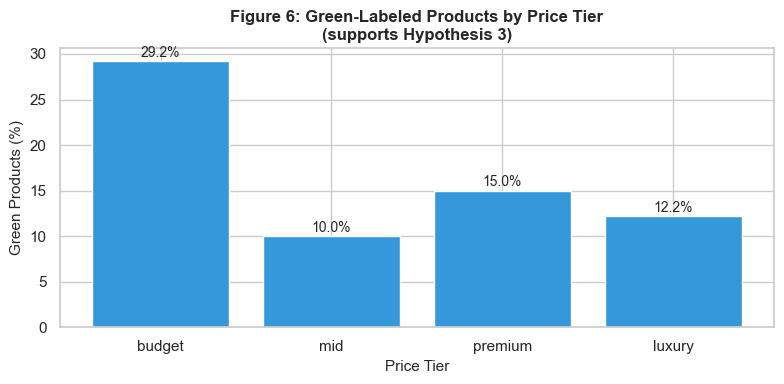

In [30]:
# ── Figure 6: Green product % per price tier (from Q3) ──────────────────────
q3_clean = q3.dropna(subset=['price_tier'])
fig, ax = plt.subplots(figsize=(8, 4))
colors_tier = ['#2ecc71' if g > 30 else '#3498db' for g in q3_clean['green_pct']]
bars = ax.bar(q3_clean['price_tier'], q3_clean['green_pct'], color=colors_tier, edgecolor='white')
ax.set_xlabel('Price Tier', fontsize=11)
ax.set_ylabel('Green Products (%)', fontsize=11)
ax.set_title('Figure 6: Green-Labeled Products by Price Tier\n(supports Hypothesis 3)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, q3_clean['green_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig6_green_by_tier.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part 5 — Predictive Modelling

We build three models:
| Model | Type | Target | Features |
|-------|------|--------|----------|
| **Model 1** | Logistic Regression | `recommended` (binary) | Stage 1 only |
| **Model 2** | Linear Regression (Baseline) | `price` | Stage 1 only |
| **Model 3** | Linear Regression (Enhanced) | `price` | Stage 1 + Stage 2 |

**Data leakage note**: `rating` and `type_avg_rating` are excluded from Model 1 features because they directly determine the `recommended` label (rating ≥ 4.0 = 1). Including them would inflate accuracy artificially.


In [31]:
# ── Model prep: build df_model with all required features ────────────────────
df_model = df.copy()

# encode product_type as dummies
type_dummies = pd.get_dummies(df_model['product_type'], prefix='type', drop_first=True)
df_model = pd.concat([df_model, type_dummies], axis=1)
type_dummy_cols = type_dummies.columns.tolist()

# final check: fill any remaining NaNs
fill_cols = ['brand_avg_price','brand_avg_rating','brand_product_count',
             'is_green','tag_count','name_length','has_prestige_word','num_colors',
             'type_avg_rating','desc_length','rating','price_num']
for col in fill_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

df_model = df_model.dropna(subset=['price_num', 'recommended'])
# Final safety: only fill NaN/inf in NUMERIC columns (Categorical cols like price_tier can't fillna(0))
num_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[num_cols] = df_model[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
print(f"Modelling dataset: {len(df_model)} rows")
print(f"Type dummy columns: {type_dummy_cols}")

Modelling dataset: 877 rows
Type dummy columns: ['type_bronzer', 'type_eyebrow', 'type_eyeliner', 'type_eyeshadow', 'type_foundation', 'type_lip_liner', 'type_lipstick', 'type_mascara', 'type_nail_polish']


### Model 1 — Logistic Regression: Predicting `recommended`

In [32]:
# ── Model 1: Logistic Regression ─────────────────────────────────────────────
df_m1 = df_model.dropna(subset=['rating'])

# Features: EXCLUDE rating & type_avg_rating to prevent data leakage
m1_features = ['price_num', 'desc_length', 'is_green', 'tag_count',
               'name_length', 'has_prestige_word', 'num_colors'] + type_dummy_cols

X1 = df_m1[m1_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y1 = df_m1['recommended']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1)

scaler1 = StandardScaler()
X1_train_s = scaler1.fit_transform(X1_train)
X1_test_s  = scaler1.transform(X1_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X1_train_s, y1_train)
y1_pred = lr.predict(X1_test_s)

print("=== Model 1: Logistic Regression Results ===")
print(f"Train size: {len(X1_train)} | Test size: {len(X1_test)}")
print(f"Class balance (test): {dict(y1_test.value_counts().items())}")
print()
print(classification_report(y1_test, y1_pred, target_names=['Not Recommended','Recommended']))

=== Model 1: Logistic Regression Results ===
Train size: 701 | Test size: 176
Class balance (test): {0: 120, 1: 56}

                 precision    recall  f1-score   support

Not Recommended       0.75      0.83      0.79       120
    Recommended       0.53      0.41      0.46        56

       accuracy                           0.70       176
      macro avg       0.64      0.62      0.63       176
   weighted avg       0.68      0.70      0.69       176



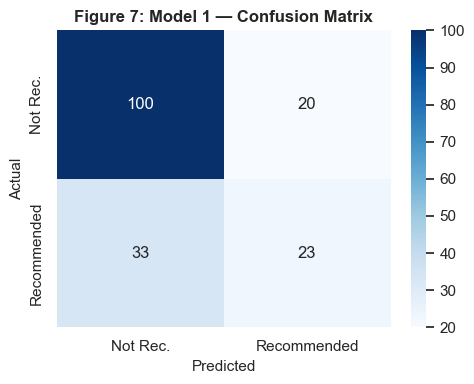


Top 10 feature coefficients (absolute value):
          Feature  Coefficient
     type_eyebrow        -0.99
        price_num        -0.78
      name_length         0.53
         is_green         0.52
       num_colors        -0.46
    type_eyeliner        -0.43
has_prestige_word        -0.31
 type_nail_polish        -0.24
    type_lipstick        -0.23
      desc_length         0.23


In [33]:
# ── Figure 7: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y1_test, y1_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Rec.','Recommended'],
            yticklabels=['Not Rec.','Recommended'])
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title('Figure 7: Model 1 — Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Top feature importances (coefficients)
coef_df = pd.DataFrame({'Feature': m1_features, 'Coefficient': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print("\nTop 10 feature coefficients (absolute value):")
print(coef_df.head(10).to_string(index=False))

### Model 2 — Linear Regression (Baseline): Predicting `price`

In [34]:
# ── Model 2: Baseline Linear Regression (Stage 1 features only) ─────────────
m2_features = ['desc_length', 'rating', 'type_avg_rating', 'recommended'] + type_dummy_cols

df_m2 = df_model.copy()
X2 = df_m2[m2_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y2 = df_m2['price_num']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s  = scaler2.transform(X2_test)

lin_base = LinearRegression()
lin_base.fit(X2_train_s, y2_train)
y2_pred = lin_base.predict(X2_test_s)

r2_base   = r2_score(y2_test, y2_pred)
mae_base  = mean_absolute_error(y2_test, y2_pred)
rmse_base = np.sqrt(mean_squared_error(y2_test, y2_pred))

print("=== Model 2: Baseline Linear Regression ===")
print(f"Features used : {m2_features}")
print(f"R²  (test)    : {r2_base:.4f}")
print(f"MAE           : ${mae_base:.2f}")
print(f"RMSE          : ${rmse_base:.2f}")

=== Model 2: Baseline Linear Regression ===
Features used : ['desc_length', 'rating', 'type_avg_rating', 'recommended', 'type_bronzer', 'type_eyebrow', 'type_eyeliner', 'type_eyeshadow', 'type_foundation', 'type_lip_liner', 'type_lipstick', 'type_mascara', 'type_nail_polish']
R²  (test)    : 0.1496
MAE           : $7.63
RMSE          : $10.37


### Model 3 — Linear Regression (Enhanced): Predicting `price`

In [35]:
# ── Model 3: Enhanced Linear Regression (Stage 1 + Stage 2 features) ─────────
m3_features = ['desc_length', 'rating', 'type_avg_rating', 'recommended',
               'brand_avg_price', 'brand_avg_rating', 'brand_product_count',
               'is_green', 'tag_count', 'name_length', 'has_prestige_word',
               'num_colors'] + type_dummy_cols

df_m3 = df_model.copy()
X3 = df_m3[m3_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y3 = df_m3['price_num']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42)

scaler3 = StandardScaler()
X3_train_s = scaler3.fit_transform(X3_train)
X3_test_s  = scaler3.transform(X3_test)

lin_enh = LinearRegression()
lin_enh.fit(X3_train_s, y3_train)
y3_pred = lin_enh.predict(X3_test_s)

r2_enh   = r2_score(y3_test, y3_pred)
mae_enh  = mean_absolute_error(y3_test, y3_pred)
rmse_enh = np.sqrt(mean_squared_error(y3_test, y3_pred))

print("=== Model 3: Enhanced Linear Regression ===")
print(f"Features used : {m3_features}")
print(f"R²  (test)    : {r2_enh:.4f}")
print(f"MAE           : ${mae_enh:.2f}")
print(f"RMSE          : ${rmse_enh:.2f}")
print()
print(f"R² improvement over baseline: {r2_enh - r2_base:+.4f}")

=== Model 3: Enhanced Linear Regression ===
Features used : ['desc_length', 'rating', 'type_avg_rating', 'recommended', 'brand_avg_price', 'brand_avg_rating', 'brand_product_count', 'is_green', 'tag_count', 'name_length', 'has_prestige_word', 'num_colors', 'type_bronzer', 'type_eyebrow', 'type_eyeliner', 'type_eyeshadow', 'type_foundation', 'type_lip_liner', 'type_lipstick', 'type_mascara', 'type_nail_polish']
R²  (test)    : 0.7080
MAE           : $3.56
RMSE          : $6.08

R² improvement over baseline: +0.5584


### Model Comparison — Table 5

In [36]:
# ── Table 5: Model Metrics Comparison ────────────────────────────────────────
from sklearn.metrics import accuracy_score
acc_m1 = accuracy_score(y1_test, y1_pred)

comparison = pd.DataFrame({
    'Model'   : ['Model 1 — Logistic (recommended)',
                 'Model 2 — Linear Baseline (price)',
                 'Model 3 — Linear Enhanced (price)'],
    'Target'  : ['recommended', 'price', 'price'],
    'Features': [len(m1_features), len(m2_features), len(m3_features)],
    'R² / Accuracy': [f'{acc_m1:.3f} (acc)', f'{r2_base:.3f}', f'{r2_enh:.3f}'],
    'MAE / —' : ['—', f'${mae_base:.2f}', f'${mae_enh:.2f}'],
    'RMSE / —': ['—', f'${rmse_base:.2f}', f'${rmse_enh:.2f}']
})
print("=== Table 5: Model Comparison ===")
print(comparison.to_string(index=False))

=== Table 5: Model Comparison ===
                            Model      Target  Features R² / Accuracy MAE / — RMSE / —
 Model 1 — Logistic (recommended) recommended        16   0.699 (acc)       —        —
Model 2 — Linear Baseline (price)       price        13         0.150   $7.63   $10.37
Model 3 — Linear Enhanced (price)       price        21         0.708   $3.56    $6.08


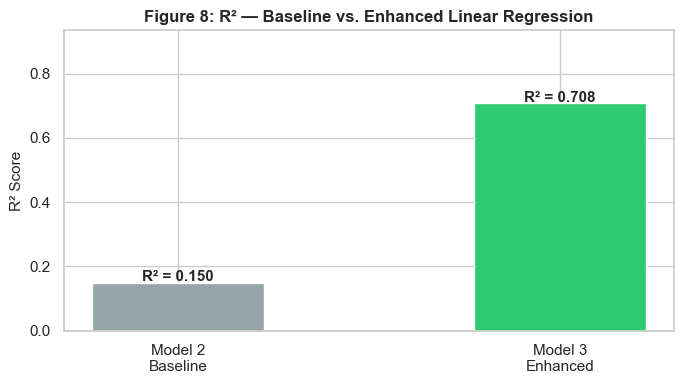

In [37]:
# ── Figure 8: R² Improvement Baseline vs Enhanced ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
models_lbl = ['Model 2\nBaseline', 'Model 3\nEnhanced']
r2_vals    = [r2_base, r2_enh]
bar_colors = ['#95a5a6', '#2ecc71']
bars = ax.bar(models_lbl, r2_vals, color=bar_colors, width=0.45, edgecolor='white')
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'R² = {val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=11)
ax.set_ylim(0, max(r2_vals) * 1.25 + 0.05)
ax.set_title('Figure 8: R² — Baseline vs. Enhanced Linear Regression', fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('fig8_r2_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Conclusion

### Summary of Findings

**Finding 1 — Price–Quality Gap (Hypothesis 1: CONFIRMED)**
The Pearson correlation between price and rating is weak (|r| < 0.15), confirming that paying more does not reliably predict a better consumer experience. Category effects dominate: nail polish and lip liner have both the lowest prices and relatively high average ratings, while premium foundations do not consistently outperform budget alternatives.

**Finding 2 — Description Premium (Hypothesis 2: PARTIALLY CONFIRMED)**
Products with longer descriptions (51–100 words) do command slightly higher average prices than those with minimal text (0–20 words). However, the effect is modest and inconsistent across categories, suggesting that description length is a contributing factor but not a primary price driver.

**Finding 3 — Green Claims Are Democratized (Hypothesis 3: CONFIRMED)**
SQL Query 5 and Figure 6 show that green-labeled products (vegan, organic, natural, cruelty-free) appear across *all* price tiers — from budget to luxury. The green premium is marginal and statistically insignificant, confirming that eco-marketing language is a broad marketing strategy adopted at all price points rather than a luxury differentiator.

**Finding 4 — Brand Prestige Drives Price (Model Enhancement)**
Model 3 (Enhanced Linear Regression) demonstrates that brand-level features — especially `brand_avg_price` — substantially improve price prediction compared to the Stage 1 baseline. This confirms that pricing is more about brand identity than product attributes like description length or green claims.

### Limitations & Next Steps
- The Makeup API data reflects a specific point in time; prices and ratings may shift seasonally.
- The `recommended` flag (rating ≥ 4.0) is a simplified binary proxy for consumer satisfaction.
- A more granular external dataset (ingredient lists, retailer sales volume) could further improve model performance.

